Original shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Scaled data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

PCA transformed data:
[[-2.26470281  0.4800266   0.12770602 -0.0241682 ]
 [-2.08096115 -0.67413356  0.23460885 -0.10300677]
 [-2.36422905 -0.34190802 -0.04420148 -0.02837705]
 [-2.29938422 -0.59739451 -0.09129011  0.06595556]
 [-2.38984217  0.64683538 -0.0157382   0.03592281]]

Shape after PCA:
(150, 4)

Principal Component directions:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942
PC3           0.719566         -0.24438

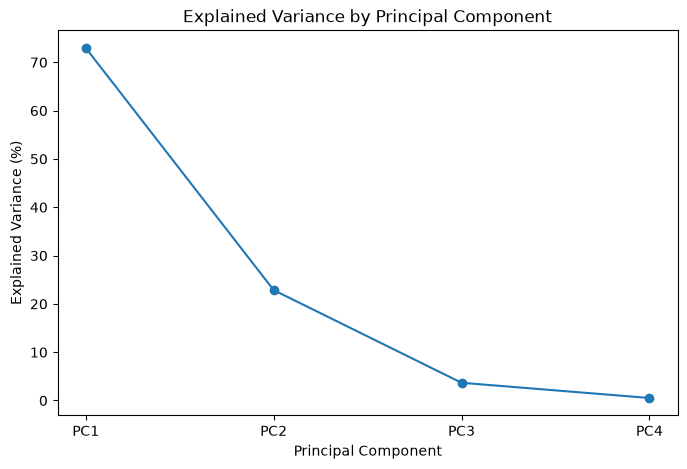

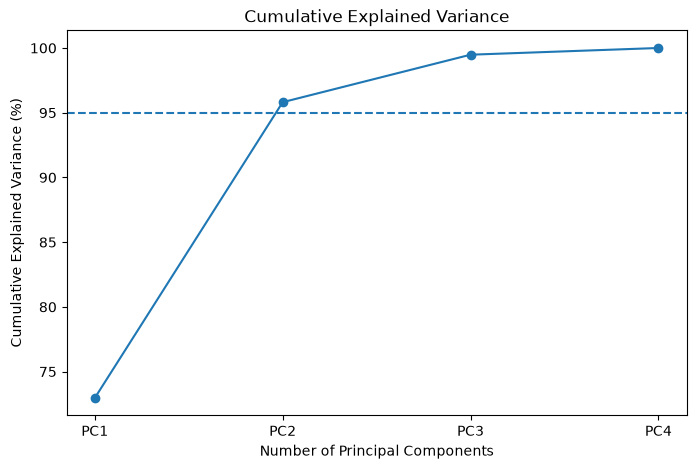


Number of PCs required for 95.0 % variance: 2

Original shape:
(150, 4)

Reduced PCA shape:
(150, 2)

Final PCA dataset:
        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835

Cluster assignments:
[1 1 1 1 1 1 1 1 1 1]


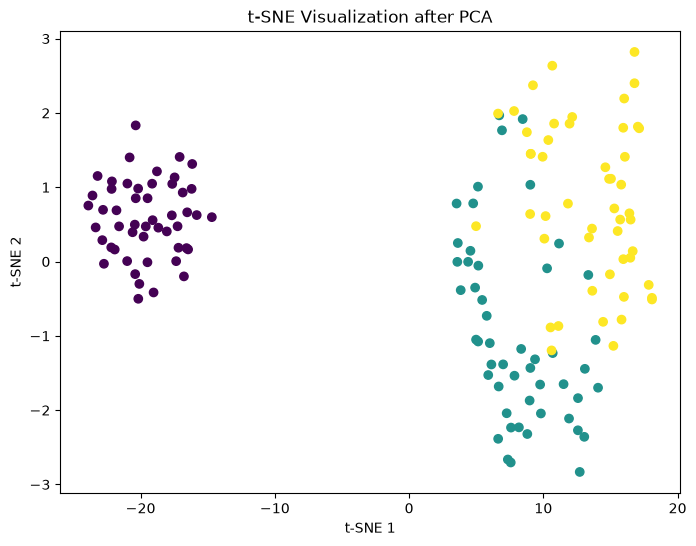

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


# ============================================================
# 2. LOAD EXISTING DATASET
# ============================================================

# Load Iris dataset
iris = load_iris()

# Input features
X = iris.data

# Target/output (only needed later if you want supervised ML)
y = iris.target

# Feature names
feature_names = iris.feature_names

print("Original shape:", X.shape)
print("Features:", feature_names)


# ============================================================
# 3. STANDARDIZE THE INPUT DATA
# ============================================================

# PCA is affected by the scale of variables.
# StandardScaler converts each feature approximately to:
# mean = 0
# standard deviation = 1

scaler = StandardScaler()

# fit_transform():
# fit  -> learns mean and standard deviation from X
# transform -> applies the scaling
X_scaled = scaler.fit_transform(X)

print("\nScaled data:")
print(X_scaled[:5])


# ============================================================
# 4. RUN PCA
# ============================================================

# n_components:
#   None      -> keep all possible components
#   2         -> directly create 2 PCs
#   0.95      -> keep enough PCs to explain 95% variance
#
# Here we use None first because we want to inspect
# ALL principal components before deciding how many to keep.

pca = PCA(
    n_components=None
)

# fit_transform():
# PCA learns the principal components
# and transforms the original data into PC space.

X_pca = pca.fit_transform(X_scaled)


# ============================================================
# 5. SEE ALL PRINCIPAL COMPONENTS
# ============================================================

print("\nPCA transformed data:")
print(X_pca[:5])

print("\nShape after PCA:")
print(X_pca.shape)


# ============================================================
# 6. PRINCIPAL COMPONENT DIRECTIONS
# ============================================================

# components_ contains the directions/loadings of each PC.
#
# Rows    -> Principal Components
# Columns -> Original features

components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[
        f"PC{i+1}"
        for i in range(len(pca.components_))
    ]
)

print("\nPrincipal Component directions:")
print(components_df)


# ============================================================
# 7. EXPLAINED VARIANCE
# ============================================================

# explained_variance_:
# Actual variance captured by each principal component.

variance_df = pd.DataFrame({
    "PC": [
        f"PC{i+1}"
        for i in range(len(pca.explained_variance_))
    ],

    "Variance": pca.explained_variance_,

    # explained_variance_ratio_ gives the fraction
    # of total variance explained by each PC.
    "Explained_Variance_Ratio":
        pca.explained_variance_ratio_,

    # Convert fraction into percentage
    "Variance_%":
        pca.explained_variance_ratio_ * 100
})

print("\nVariance explained by each PC:")
print(variance_df)


# ============================================================
# 8. CUMULATIVE EXPLAINED VARIANCE
# ============================================================

# cumsum() adds the variance percentages cumulatively.
#
# Example:
# PC1 = 73%
# PC2 = 23%
#
# Cumulative:
# PC1 = 73%
# PC1 + PC2 = 96%

variance_df["Cumulative_Variance_%"] = (
    variance_df["Variance_%"].cumsum()
)

print("\nCumulative explained variance:")
print(variance_df)


# ============================================================
# 9. SORT PCs BY EXPLAINED VARIANCE
# ============================================================

# PCA normally already returns PCs in descending order
# of explained variance.
#
# PC1 -> maximum variance
# PC2 -> second maximum
# PC3 -> third maximum
# etc.

variance_sorted = variance_df.sort_values(
    by="Variance_%",
    ascending=False
)

print("\nPCs sorted by explained variance:")
print(variance_sorted)


# ============================================================
# 10. SCREE PLOT
# ============================================================

# Shows how much variance each PC explains.

plt.figure(figsize=(8, 5))

plt.plot(
    variance_df["PC"],
    variance_df["Variance_%"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")

plt.show()


# ============================================================
# 11. CUMULATIVE VARIANCE PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    variance_df["PC"],
    variance_df["Cumulative_Variance_%"],
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

# Example threshold
plt.axhline(
    y=95,
    linestyle="--"
)

plt.show()


# ============================================================
# 12. DECIDE NUMBER OF PCs
# ============================================================

# Suppose we want to retain at least 95% of the variance.

variance_threshold = 0.95

# Find the smallest number of PCs whose cumulative
# explained variance reaches 95%.

n_components = (
    pca.explained_variance_ratio_.cumsum()
    >= variance_threshold
).argmax() + 1

print(
    "\nNumber of PCs required for",
    variance_threshold * 100,
    "% variance:",
    n_components
)


# ============================================================
# 13. CREATE PCA AGAIN WITH SELECTED NUMBER OF PCs
# ============================================================

# Now that we know how many PCs we need,
# create PCA using only those components.

pca_final = PCA(
    n_components=n_components
)

# Transform original standardized data
X_pca_final = pca_final.fit_transform(X_scaled)

print("\nOriginal shape:")
print(X.shape)

print("\nReduced PCA shape:")
print(X_pca_final.shape)


# ============================================================
# 14. SEE FINAL PCA DATA
# ============================================================

# Create a DataFrame containing only the selected PCs.

pc_columns = [
    f"PC{i+1}"
    for i in range(n_components)
]

X_pca_df = pd.DataFrame(
    X_pca_final,
    columns=pc_columns
)

print("\nFinal PCA dataset:")
print(X_pca_df.head())


# ============================================================
# 15. APPLY ML MODEL ON PCA DATA
# ============================================================

# Example: K-Means clustering
#
# PCA data can now be supplied to an ML algorithm
# instead of the original high-dimensional data.

kmeans = KMeans(
    n_clusters=3,     # Number of clusters
    random_state=42,  # Makes result reproducible
    n_init=10         # Number of initializations
)

clusters = kmeans.fit_predict(X_pca_final)

print("\nCluster assignments:")
print(clusters[:10])


# ============================================================
# 16. t-SNE VISUALIZATION
# ============================================================

# t-SNE is mainly used for visualization.
#
# We can apply t-SNE AFTER PCA.
#
# PCA first reduces noise/dimensionality.
# t-SNE then maps the data into 2 dimensions
# for visualization.

tsne = TSNE(
    n_components=2,   # Always 2 here for 2D visualization
    perplexity=30,    # Important hyperparameter
    learning_rate="auto",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca_final)


# ============================================================
# 17. VISUALIZE t-SNE RESULT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization after PCA")

plt.show()